# Hospital Catchment Area Analytics in the Inland Empire

## A Reproducible GIS Workflow for Healthcare Accessibility Analysis

**Author**

Sara Javaheri

Graduate Research Assistant

California State University, San Bernardino

---

**Faculty Mentor**

Benjamin J. Becerra

Assistant Professor

School of Cyber and Decision Sciences

California State University, San Bernardino

---

### Study Area

- Riverside County
- San Bernardino County
- California

---

### Research Areas

- Geographic Information Systems (GIS)
- Spatial Data Science
- Healthcare Accessibility
- Public Health Analytics
- Python Programming

# Abstract

This notebook documents the complete geospatial data preparation workflow developed for healthcare accessibility analysis in California's Inland Empire.

The workflow integrates multiple public datasets, including Census tract boundaries, American Community Survey (ACS) demographic data, CDC PLACES health indicators, CMS hospital information, HRSA health centers, and OpenStreetMap road networks.

Rather than presenting only the final datasets, this notebook documents every stage of data acquisition, filtering, spatial integration, geocoding, validation, and visualization. The resulting integrated geospatial database establishes the analytical foundation for future hospital catchment area modeling and healthcare accessibility research.

# 1. Introduction

Healthcare accessibility is a fundamental component of public health planning, influencing the ability of individuals to obtain timely medical care and preventive health services. Geographic disparities in access to healthcare facilities may contribute to unequal health outcomes, particularly in rapidly growing metropolitan regions where population growth and healthcare infrastructure do not always develop at the same pace.

California's Inland Empire, consisting of Riverside County and San Bernardino County, has experienced substantial demographic growth while continuing to exhibit geographic and socioeconomic diversity. Understanding the spatial relationship between population characteristics and healthcare resources requires the integration of multiple geospatial datasets into a unified analytical framework.

The objective of this notebook is to document the complete data engineering workflow used to construct that framework. The workflow integrates official census tract boundaries, demographic characteristics, public health indicators, hospital locations, federally supported health centers, and transportation data into a reproducible geospatial database suitable for healthcare accessibility research.

# 1. Study Area

## Overview

This research focuses on California's Inland Empire, consisting of Riverside County and San Bernardino County. Together, these counties represent one of the fastest-growing metropolitan regions in the United States and exhibit substantial demographic diversity, geographic variation, and disparities in healthcare accessibility.

The study area was selected because it contains rapidly expanding urban communities, large rural regions, and populations experiencing varying levels of healthcare access. These characteristics make the Inland Empire an appropriate case study for evaluating spatial accessibility to healthcare facilities.

Throughout this notebook, all demographic, health, healthcare facility, and transportation datasets are spatially standardized to this geographic extent before integration into a unified geospatial database.

# 2. Preparing Census Tract Boundaries

## Objective

The first stage of this study establishes the geographic framework that will be used throughout the remainder of the analysis. Census tracts were selected as the primary spatial unit because all demographic, public health, and healthcare facility datasets used in this project can be linked directly or indirectly to tract-level geography.

The official TIGER/Line Census Tract Shapefile published by the U.S. Census Bureau was used as the spatial backbone of the project. Since the research focuses exclusively on California's Inland Empire, only census tracts belonging to Riverside County and San Bernardino County were retained for subsequent analyses.

The prepared tract layer serves as the geographic reference for integrating demographic information from the American Community Survey (ACS), health indicators from CDC PLACES, healthcare facility locations, and future accessibility analyses.

## Data Source

**Dataset:** TIGER/Line Census Tracts (2025 Release)

**Provider:** U.S. Census Bureau

**File Used**

```
Datasets/tl_2025_06_tract.shp
```

This dataset contains the official census tract boundaries for the State of California together with geographic identifiers (GEOID), county codes, tract names, and polygon geometries required for spatial analysis.

In [6]:
import geopandas as gpd

# Load data
tracts = gpd.read_file("data/raw/tl_2025_06_tract.shp")


In [7]:
tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,06,065,042516,06065042516,1400000US06065042516,425.16,Census Tract 425.16,G5020,S,973130,0,+33.9227363,-117.2393879,"POLYGON ((-117.24375 33.92818, -117.24323 33.9..."
1,06,065,042716,06065042716,1400000US06065042716,427.16,Census Tract 427.16,G5020,S,2698784,711913,+33.6865062,-117.2551285,"POLYGON ((-117.27209 33.68473, -117.27117 33.6..."
2,06,065,042717,06065042717,1400000US06065042717,427.17,Census Tract 427.17,G5020,S,6425166,145210,+33.6997108,-117.2534257,"POLYGON ((-117.26908 33.70438, -117.26882 33.7..."
3,06,065,042902,06065042902,1400000US06065042902,429.02,Census Tract 429.02,G5020,S,43393952,0,+33.7493422,-117.3068291,"POLYGON ((-117.34733 33.78247, -117.34732 33.7..."
4,06,065,042903,06065042903,1400000US06065042903,429.03,Census Tract 429.03,G5020,S,44642454,0,+33.8027798,-117.3133054,"POLYGON ((-117.36332 33.8294, -117.36331 33.82..."


### Initial Inspection

The successful loading of the TIGER/Line dataset confirms that the statewide census tract boundaries are available for analysis. Each record represents a single census tract together with descriptive attributes and polygon geometry.

Before integrating demographic and health datasets, the statewide dataset must be restricted to the study area consisting of Riverside County and San Bernardino County.

In [8]:
# Filter to Riverside (county code: 065) and San Bernardino (071)
ie_tracts = tracts[tracts["COUNTYFP"].isin(["065", "071"])]


In [9]:
ie_tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,06,065,042516,06065042516,1400000US06065042516,425.16,Census Tract 425.16,G5020,S,973130,0,+33.9227363,-117.2393879,"POLYGON ((-117.24375 33.92818, -117.24323 33.9..."
1,06,065,042716,06065042716,1400000US06065042716,427.16,Census Tract 427.16,G5020,S,2698784,711913,+33.6865062,-117.2551285,"POLYGON ((-117.27209 33.68473, -117.27117 33.6..."
2,06,065,042717,06065042717,1400000US06065042717,427.17,Census Tract 427.17,G5020,S,6425166,145210,+33.6997108,-117.2534257,"POLYGON ((-117.26908 33.70438, -117.26882 33.7..."
3,06,065,042902,06065042902,1400000US06065042902,429.02,Census Tract 429.02,G5020,S,43393952,0,+33.7493422,-117.3068291,"POLYGON ((-117.34733 33.78247, -117.34732 33.7..."
4,06,065,042903,06065042903,1400000US06065042903,429.03,Census Tract 429.03,G5020,S,44642454,0,+33.8027798,-117.3133054,"POLYGON ((-117.36332 33.8294, -117.36331 33.82..."


### Dataset Inspection

The preview shown above provides an initial inspection of the statewide TIGER/Line census tract dataset. Each row represents a unique census tract and includes administrative attributes such as county identifiers and geographic boundaries stored as polygon geometries.

Before these tract boundaries can support healthcare accessibility analysis, the dataset must be restricted to the Inland Empire study area, consisting of Riverside County and San Bernardino County.

In [5]:
print(f"Total California tracts: {len(tracts)}")
print(f"Inland Empire tracts: {len(ie_tracts)}")

Total California tracts: 9129
Inland Empire tracts: 984


**Table 1. Census tract counts before and after filtering**

The table above summarizes the reduction of the statewide TIGER/Line dataset to the Inland Empire study area. Filtering the dataset decreases the number of census tracts while preserving all tracts located within Riverside County and San Bernardino County.

### Filtering Results

The filtering procedure successfully isolated the census tracts belonging to Riverside County and San Bernardino County. This subset represents the geographic extent of the Inland Empire and forms the spatial foundation for all subsequent analyses.

Restricting the dataset to the study area reduces computational complexity while ensuring that all downstream processing focuses exclusively on the region of interest.

### 2.3 Coordinate Reference System Standardization

Geospatial datasets may use different coordinate reference systems, which can create alignment problems during mapping and spatial integration. To establish a consistent geographic reference, the filtered Inland Empire census tract layer is converted to EPSG:4326.

EPSG:4326 represents geographic coordinates using latitude and longitude. This coordinate system is commonly used for web mapping, geocoding, and integrating spatial datasets obtained from different public sources.

In [13]:
# Convert coordinates to EPSG:4326
ie_tracts = ie_tracts.to_crs(epsg=4326)

### 2.4 Exporting the Prepared Census Tract Layer

After filtering and coordinate-system standardization, the resulting census tract layer is saved as a GeoPackage. The GeoPackage format preserves both geographic geometry and attribute information in a single file and is compatible with Python, ArcGIS Pro, and QGIS.

The exported file becomes the spatial foundation for the next stages of the workflow, including integration with ACS demographic data and CDC PLACES health indicators.

In [15]:
# Save
ie_tracts.to_file("data/raw/ie_tracts.gpkg", driver="GPKG")
print(ie_tracts.head())
print(ie_tracts.shape)

  STATEFP COUNTYFP TRACTCE        GEOID               GEOIDFQ    NAME  \
0      06      065  042516  06065042516  1400000US06065042516  425.16   
1      06      065  042716  06065042716  1400000US06065042716  427.16   
2      06      065  042717  06065042717  1400000US06065042717  427.17   
3      06      065  042902  06065042902  1400000US06065042902  429.02   
4      06      065  042903  06065042903  1400000US06065042903  429.03   

              NAMELSAD  MTFCC FUNCSTAT     ALAND  AWATER     INTPTLAT  \
0  Census Tract 425.16  G5020        S    973130       0  +33.9227363   
1  Census Tract 427.16  G5020        S   2698784  711913  +33.6865062   
2  Census Tract 427.17  G5020        S   6425166  145210  +33.6997108   
3  Census Tract 429.02  G5020        S  43393952       0  +33.7493422   
4  Census Tract 429.03  G5020        S  44642454       0  +33.8027798   

       INTPTLON                                           geometry  
0  -117.2393879  POLYGON ((-117.24375 33.92818, -117.

### 2.5 Result and Interpretation

The census tract preparation stage produced a geospatial dataset containing only the tracts located in Riverside County and San Bernardino County. The layer was standardized to EPSG:4326 and saved as `ie_tracts.gpkg`.

This output serves as the common geographic framework for subsequent data integration. In the next stage, tract-level demographic and socioeconomic variables from the American Community Survey will be retrieved and linked to these boundaries through the census tract GEOID.

# 3. American Community Survey (ACS) Demographic Data

## Objective

After establishing the census tract boundaries for the Inland Empire, the next stage of the workflow incorporates tract-level demographic and socioeconomic characteristics.

The American Community Survey (ACS) 5-Year Estimates were used because they provide demographic information at the census tract level, allowing population characteristics to be linked directly to the spatial framework prepared in the previous section.

The variables retrieved in this stage include total population, median household income, health insurance, White population, and Black population. These variables provide demographic context for later evaluation of geographic differences in healthcare accessibility.

## Data Source

**Dataset:** American Community Survey (ACS) 5-Year Estimates

**Provider:** U.S. Census Bureau

**Geographic Level:** Census tract

**Study Area:** Riverside County and San Bernardino County, California

The ACS provides demographic and socioeconomic estimates for small geographic areas. In this workflow, the Census API is used to retrieve tract-level observations separately for Riverside County and San Bernardino County before combining them into a single analytical dataset.

In [23]:
from census import Census
import pandas as pd

import os
API_KEY = os.environ.get("CENSUS_API_KEY")  # set this in your environment, never hardcode it
c = Census(API_KEY)


> **Reproducibility and security note:** A U.S. Census Bureau API key is required to execute the following data-acquisition step. The key used during the original analysis has been omitted from this public research notebook for security purposes.

In [24]:
fields = (
    'NAME',
    'B01003_001E',  # total population
    'B19013_001E',  # median household income
    'B27001_001E',  # population with health insurance
    'B02001_002E',  # White population
    'B02001_003E',  # Black population
)

### ACS Variables

Five tract-level measures were selected for the initial demographic database:

- **Total population** — used to characterize the population represented by each census tract.
- **Median household income** — provides socioeconomic context for examining potential differences in healthcare access.
- **Health insurance** — provides an indicator related to healthcare coverage.
- **White population** and **Black population** — provide selected racial population counts for demographic characterization of the study area.

The Census variable codes are retained in the acquisition step and are renamed to more interpretable field names after retrieval.

In [25]:
# Riverside County (065)
riverside = c.acs5.state_county_tract(fields, '06', '065', Census.ALL)
df_riverside = pd.DataFrame(riverside)

### Riverside County Retrieval

The Census API is queried for all census tracts in Riverside County using California state FIPS code `06` and Riverside County FIPS code `065`. The returned records are converted to a pandas DataFrame for subsequent integration.

In [26]:
# San Bernardino County (071)
sanbernardino = c.acs5.state_county_tract(fields, '06', '071', Census.ALL)
df_sb = pd.DataFrame(sanbernardino)

### San Bernardino County Retrieval

The same ACS variables are retrieved for all census tracts in San Bernardino County using county FIPS code `071`. Maintaining identical variables and geographic resolution for both counties ensures that the two datasets can be combined directly.

In [39]:
#Combine both counties
df = pd.concat([df_riverside, df_sb], ignore_index=True)

df.head()

,NAME,B01003_001E,B19013_001E,B27001_001E,B02001_002E,B02001_003E,state,county,tract
0,Census Tract 301.01; Riverside County; California,1173.0,78000.0,1163.0,219.0,50.0,06,065,030101
1,Census Tract 301.03; Riverside County; California,2170.0,95670.0,2165.0,400.0,170.0,06,065,030103
2,Census Tract 301.04; Riverside County; California,7610.0,102000.0,7610.0,2280.0,1032.0,06,065,030104
3,Census Tract 302; Riverside County; California,4507.0,89971.0,4507.0,1936.0,642.0,06,065,030200
4,Census Tract 303; Riverside County; California,4390.0,62490.0,4106.0,1712.0,503.0,06,065,030300


### Combining the Study Area

The Riverside and San Bernardino tract-level datasets are concatenated into a single DataFrame representing the complete Inland Empire study area.

In [40]:
# Construct GEOID for joining with TIGER
df['GEOID'] = df['state'] + df['county'] + df['tract']

### Constructing the Census Tract GEOID

A standardized census tract GEOID is created by concatenating the state, county, and tract identifiers returned by the Census API.

This field is critical because it provides the standard key required to join the ACS demographic dataset to the TIGER/Line census tract boundaries prepared in the previous section.

In [41]:
# Rename variables
df.rename(columns={
    'B01003_001E': 'total_population',
    'B19013_001E': 'median_income',
    'B27001_001E': 'health_insurance',
    'B02001_002E': 'pop_white',
    'B02001_003E': 'pop_black',
}, inplace=True)

### Variable Renaming

The original Census API variable identifiers are renamed to descriptive field names. This improves readability and reduces ambiguity during later data integration and interpretation.

### Analytical Data Integration Framework

The data integration strategy distinguishes between two conceptually different components of the healthcare accessibility system: population-based demand/need and healthcare facility supply.

Census tracts serve as the common geographic unit for representing population characteristics and health-related need. The TIGER/Line tract layer provides the spatial geometry and geographic identifiers, while ACS and CDC PLACES provide complementary tract-level demographic, socioeconomic, and health measures. Because these datasets describe the same geographic units, they are integrated through the Census tract GEOID, producing a rich tract-level analytical dataset in which each record represents one census tract and contains its spatial boundary together with population, socioeconomic, and health attributes.

Healthcare facilities are treated separately as the supply component of the accessibility system. CMS hospitals and HRSA health centers represent individual facility locations rather than census-tract observations. Therefore, they are not incorporated into the tract dataset through the same attribute-based GEOID join. Instead, facility locations are represented as spatial point features and are subsequently related to population tracts through spatial and accessibility relationships, including geographic location, travel-time networks, and catchment-area models.

Maintaining this distinction between tract-level population need and point-based healthcare supply preserves the unit of analysis of each source dataset and provides the analytical structure required for subsequent healthcare accessibility and catchment-area modeling.

In [46]:
# Save
df.to_csv('data/processed/acs_inland_empire.csv', index=False)
print(df.head())
print(df['county'].value_counts())
print(f"Total mumber of tracts: {len(df)}")

                                                NAME  total_population  \
0  Census Tract 301.01; Riverside County; California            1173.0   
1  Census Tract 301.03; Riverside County; California            2170.0   
2  Census Tract 301.04; Riverside County; California            7610.0   
3     Census Tract 302; Riverside County; California            4507.0   
4     Census Tract 303; Riverside County; California            4390.0   

   median_income  health_insurance  pop_white  pop_black state county   tract  \
0        78000.0            1163.0      219.0       50.0    06    065  030101   
1        95670.0            2165.0      400.0      170.0    06    065  030103   
2       102000.0            7610.0     2280.0     1032.0    06    065  030104   
3        89971.0            4507.0     1936.0      642.0    06    065  030200   
4        62490.0            4106.0     1712.0      503.0    06    065  030300   

         GEOID  
0  06065030101  
1  06065030103  
2  06065030104  


### Result and Interpretation

The ACS acquisition stage produces a single tract-level demographic dataset for Riverside and San Bernardino Counties and saves it as `acs_inland_empire.csv`.

Each record contains the selected demographic variables together with a standardized GEOID. This GEOID provides the link between the tabular ACS data and the census tract geometry prepared earlier.

The resulting file is therefore ready for spatial integration in the next stage of the workflow.

# 4. Integrating Census Tracts with ACS Demographic Data

## Objective

The previous sections produced two complementary datasets:

- A geospatial census tract layer for the Inland Empire.
- A tract-level demographic dataset obtained from the American Community Survey (ACS).

The objective of this stage is to integrate these datasets into a single geospatial database by joining demographic attributes to the corresponding census tract polygons using the standardized GEOID identifier.

The resulting dataset forms the foundation for all subsequent spatial analyses performed in this study.

## Input Datasets

This stage combines two datasets created in the previous sections:

- **ie_tracts.gpkg** – Census tract boundaries for Riverside County and San Bernardino County.
- **acs_inland_empire.csv** – ACS demographic and socioeconomic variables.

Both datasets contain a common GEOID field, allowing a one-to-one attribute join between census tract geometry and demographic information.

## Input Datasets

This stage combines two datasets created in the previous sections:

- **ie_tracts.gpkg** – Census tract boundaries for Riverside County and San Bernardino County.
- **acs_inland_empire.csv** – ACS demographic and socioeconomic variables.

Both datasets contain a common GEOID field, allowing a one-to-one attribute join between census tract geometry and demographic information.

In [47]:
import geopandas as gpd
import pandas as pd

# Load census tract layer
tracts = gpd.read_file("ie_tracts.gpkg")

# Load ACS data
acs = pd.read_csv("acs_inland_empire.csv", dtype={'GEOID': str})

### Loading the Input Data

The prepared census tract layer and ACS demographic dataset are loaded into Python.

The ACS GEOID field is explicitly read as a string to preserve leading zeros, ensuring compatibility with the GEOID stored in the census tract layer.

In [48]:
# Join using GEOID
tracts['GEOID'] = tracts['GEOID'].astype(str)
merged = tracts.merge(acs, on='GEOID', how='left')

### Joining Spatial and Demographic Data

The GEOID field serves as the unique identifier linking each census tract polygon to its corresponding demographic attributes.

A left join is used to preserve every census tract in the study area while attaching demographic information wherever a matching GEOID exists.

In [49]:
merged.to_file("ie_tracts_acs.gpkg", driver="GPKG")

print(f"Number of census tracts: {len(merged)}")
print(merged[['GEOID', 'total_population', 'median_income']].head())
print(merged.shape)
print(merged[['GEOID', 'total_population', 'median_income']].isnull().sum())

Number of census tracts: 984
         GEOID  total_population  median_income
0  06065042516            3762.0        77604.0
1  06065042716            5842.0       129750.0
2  06065042717            6307.0        78502.0
3  06065042902            4774.0        55078.0
4  06065042903            5213.0        63268.0
(984, 23)
GEOID               0
total_population    0
median_income       0
dtype: int64


### Result and Interpretation

The spatial join successfully integrates demographic information with census tract geometry, producing a single geospatial dataset named **ie_tracts_acs.gpkg**.

This dataset now contains both spatial boundaries and demographic attributes, making it suitable for mapping, exploratory spatial analysis, healthcare accessibility analysis, and subsequent integration with additional datasets such as CDC PLACES, healthcare facilities, and transportation networks.

As this merged dataset combines geometry and demographic variables, it becomes the primary analytical dataset for the remainder of the research workflow.

# 5. Preparing CDC PLACES Health Indicator Data

## Objective

The next stage incorporates tract-level public health indicators from the CDC PLACES dataset.

Because the original PLACES dataset contains census tract estimates for locations across the United States, the dataset is filtered to retain only records associated with Riverside County and San Bernardino County.

This step produces a study-area-specific health dataset that can later be joined to the census tract and ACS dataset using tract-level geographic identifiers.

## Data Source

**Dataset:** CDC PLACES Census Tract Data

**Provider:** Centers for Disease Control and Prevention (CDC)

**Geographic Level:** Census tract

The PLACES dataset contains model-based estimates of health outcomes, health behaviors, and preventive health measures. In this workflow, the dataset is restricted to the Inland Empire before being integrated with the existing spatial database.

In [74]:
import pandas as pd

places = pd.read_csv(
    "data/processed/PLACES__Census_Tract_Data_(GIS_Friendly_Format),_2024_release_20260718.csv",
    dtype={'tractfips': str}
)

### Loading the PLACES Dataset

The CDC PLACES census tract dataset is loaded into a pandas DataFrame. The tract FIPS field is read as a string to preserve the complete geographic identifier for subsequent spatial integration.

In [75]:
# Filter Riverside and San Bernardino
places_ie = places[
    places['CountyFIPS'].isin([6065, 6071])
]

### Filtering to the Inland Empire

The statewide or national PLACES dataset is restricted to census tracts within Riverside County and San Bernardino County using county FIPS codes.

This filtering step ensures that subsequent health-data integration is limited to the same geographic extent used throughout the study.

In [76]:
places_ie.to_csv("data/processed/places_inland_empire.csv", index=False)

print(f"Number of tracts: {len(places_ie)}")
print(f"Number of tracts: {len(places_ie)}")

Number of tracts: 982
Number of tracts: 982


### Result and Interpretation

The filtering process produces a study-area-specific CDC PLACES dataset named **places_inland_empire.csv**.

This file contains tract-level public health indicators for Riverside County and San Bernardino County and is prepared for integration with the existing census tract and ACS geospatial database.

The next stage joins these health indicators to the spatial dataset using the census tract geographic identifier.

# 6. Integrating CDC PLACES Health Indicators with Census Tracts and ACS Data

## Research Objective

At this stage, the demographic dataset created in the previous sections is enriched with tract-level public health indicators obtained from the CDC PLACES dataset.

Because both datasets describe the same census tract geography, they can be integrated using the official census tract identifier (GEOID). The resulting geospatial dataset combines geometry, demographic characteristics, socioeconomic variables, and health indicators into a single analytical layer that will support the remaining stages of the research.

## Methodological Justification

Before integrating the CDC PLACES dataset with the existing census tract database, it is necessary to verify that both datasets describe the same geographic unit.

The TIGER/Line census tract dataset identifies each tract using the field **GEOID**, which is the official 11-digit Census tract geographic identifier.

The CDC PLACES dataset identifies census tracts using the field **tractfips**, which the CDC defines as the Census tract FIPS code.

Although the field names differ, both fields represent the same official Census tract identifier. Therefore, the PLACES `tractfips` field can be standardized to the `GEOID` format before performing the attribute join.

## Input Datasets

This integration step combines the following datasets:

| Dataset | Description | Geometry |
|----------|-------------|----------|
| **ie_tracts_acs.gpkg** | Census tract boundaries enriched with ACS demographic and socioeconomic variables | Polygon |
| **places_inland_empire.csv** | CDC PLACES tract-level public health indicators | Tabular (CSV) |

The first dataset provides the spatial framework for the study, while the second provides health indicators that will be attached to each census tract using the official census tract identifier.

In [91]:
import geopandas as gpd
import pandas as pd

# Load previous file
merged = gpd.read_file("data/processed/ie_tracts_acs.gpkg")

# Load CDC PLACES
places = pd.read_csv(
    "data/processed/places_inland_empire.csv",
    dtype={'TractFIPS': str}
)

### Loading the Input Datasets

The first step loads the two datasets prepared in the previous stages of the workflow.

- **ie_tracts_acs.gpkg** is loaded as a GeoDataFrame because it contains census tract polygons together with ACS demographic and socioeconomic attributes.
- **places_inland_empire.csv** is loaded as a pandas DataFrame because it contains only tabular health indicators referenced by census tract identifiers.

At this stage, no spatial operations are performed. The objective is simply to load both datasets into memory for subsequent integration.

### Geographic Identifier Evidence

The CDC PLACES dataset includes a field named **TractFIPS** (`tractfips`), which the CDC documentation defines as the **Census tract FIPS code**.

The TIGER/Line census tract dataset uses the field **GEOID** to identify census geographic entities. TIGER/Line files contain geographic entity codes specifically designed to support linkage with Census data.

For this project, both identifiers refer to the census tract geographic unit. The PLACES tract identifier is therefore standardized to the same 11-character format used by the TIGER/Line `GEOID` before the datasets are joined.

In [93]:
# Standardize GEOID for joining
merged['GEOID'] = merged['GEOID'].astype(str)
places['GEOID'] = places['TractFIPS'].str.zfill(11)

### Standardizing the Join Key

The two datasets store census tract identifiers using different field names and potentially different string formatting.

To prevent failed matches caused by missing leading zeros, the CDC PLACES `tractfips` values are standardized to an 11-character string before being assigned to the common `GEOID` field.

No geographic transformation occurs in this step. The operation only standardizes the representation of the tract identifier so that equivalent census tracts can be matched consistently across the two datasets.

In [94]:
final = merged.merge(places, on='GEOID', how='left')

### Join Strategy: Preserving the Census Tract Framework

The CDC PLACES attributes are integrated with the existing census tract–ACS GeoDataFrame using a **left join**.

The census tract GeoDataFrame is placed on the left side of the join because it represents the established spatial framework of the study area. A left join preserves all census tract polygons in this dataset, including any tract for which a corresponding CDC PLACES record is unavailable.

This approach is important because unmatched health records should appear as missing attribute values rather than causing the corresponding census tract polygon to be removed from the study-area dataset.

In [96]:
# Merge
final = merged.merge(places, on='GEOID', how='left')

### Validation Approach

After the join, the workflow checks the resulting dataset by examining the number of census tracts and reviewing selected demographic and health variables.

These checks help confirm that the merged dataset was created successfully and that tract-level attributes are present in the resulting GeoDataFrame.

It is important to note that this script performs a basic structural validation of the merge. A more detailed assessment of unmatched GEOIDs or missing health records would require additional validation code beyond the current script.

### Result and Interpretation

The integration produces `ie_tracts_final.gpkg`, a tract-level geospatial dataset containing census tract geometry, ACS demographic and socioeconomic variables, and CDC PLACES health indicators.

The sample output confirms that demographic variables such as total population and median household income are available alongside health indicators such as diabetes prevalence and limited healthcare access.

This integrated tract-level dataset becomes the primary population and health context layer for the next stages of the project, where healthcare facility datasets are introduced.

### Validation of the Data Integration

Following the attribute join, the resulting dataset is inspected to confirm that the census tract framework has been preserved and that selected ACS and CDC PLACES variables are present in the integrated dataset.

The validation performed in the original workflow includes:

- checking the total number of census tract records after the join; and
- inspecting selected demographic and health variables in the first several records.

These checks provide an initial assessment of the structure of the integrated dataset. They do not, however, constitute a complete assessment of unmatched tract identifiers or missing PLACES observations.

In [99]:
# Save
final.to_file("data/processed/ie_tracts_final.gpkg", driver="GPKG")

print(f"Number of tracts: {len(final)}")
print(final[['GEOID', 'total_population', 'median_income', 'DIABETES_CrudePrev', 'ACCESS2_CrudePrev']].head())

Number of tracts: 984
         GEOID  total_population  median_income  DIABETES_CrudePrev  \
0  06065042516            3762.0        77604.0                12.6   
1  06065042716            5842.0       129750.0                10.7   
2  06065042717            6307.0        78502.0                12.0   
3  06065042902            4774.0        55078.0                15.0   
4  06065042903            5213.0        63268.0                14.3   

   ACCESS2_CrudePrev  
0               19.4  
1                5.9  
2               14.9  
3               22.3  
4               21.9  


In [100]:
# Check CDC PLACES coverage after the join
print("Total tracts:", len(final))

print(
    "Tracts with CDC diabetes data:",
    final["DIABETES_CrudePrev"].notna().sum()
)

print(
    "Tracts missing CDC diabetes data:",
    final["DIABETES_CrudePrev"].isna().sum()
)

print(
    "Percent with CDC data:",
    round(final["DIABETES_CrudePrev"].notna().mean() * 100, 2),
    "%"
)

Total tracts: 984
Tracts with CDC diabetes data: 982
Tracts missing CDC diabetes data: 2
Percent with CDC data: 99.8 %


In [103]:
print(final["total_population"].head())

0    3762.0
1    5842.0
2    6307.0
3    4774.0
4    5213.0
Name: total_population, dtype: float64


In [101]:
# Inspect tracts with missing CDC diabetes estimates
missing_diabetes = final[
    final["DIABETES_CrudePrev"].isna()
]

print("Number of tracts:", len(missing_diabetes))

print(
    missing_diabetes[
        ["GEOID", "total_population", "median_income",
         "DIABETES_CrudePrev", "ACCESS2_CrudePrev"]
    ]
)

Number of tracts: 2
           GEOID  total_population  median_income  DIABETES_CrudePrev  \
211  06065980004               0.0   -666666666.0                 NaN   
879  06071980100               3.0   -666666666.0                 NaN   

     ACCESS2_CrudePrev  
211                NaN  
879                NaN  


In [104]:
# Check whether the two GEOIDs exist in the original CDC PLACES table

check_geoids = ["06065980004", "06071980100"]

places_check = places[
    places["GEOID"].isin(check_geoids)
]

print("CDC records found:", len(places_check))

print(
    places_check[
        ["GEOID", "DIABETES_CrudePrev", "ACCESS2_CrudePrev"]
    ]
)

CDC records found: 0
Empty DataFrame
Columns: [GEOID, DIABETES_CrudePrev, ACCESS2_CrudePrev]
Index: []


In [105]:
# Validate GEOID matching between study-area tracts and CDC PLACES

study_geoids = set(final["GEOID"])
cdc_geoids = set(places["GEOID"])

matched_geoids = study_geoids.intersection(cdc_geoids)
unmatched_geoids = study_geoids.difference(cdc_geoids)

print("Study-area GEOIDs:", len(study_geoids))
print("Matched with CDC:", len(matched_geoids))
print("Unmatched with CDC:", len(unmatched_geoids))
print("Match rate:", round(len(matched_geoids) / len(study_geoids) * 100, 2), "%")

print("\nUnmatched GEOIDs:")
print(sorted(unmatched_geoids))

Study-area GEOIDs: 984
Matched with CDC: 982
Unmatched with CDC: 2
Match rate: 99.8 %

Unmatched GEOIDs:
['06065980004', '06071980100']


### Validation of CDC PLACES Coverage

The study area contains 984 census tracts, of which 982 were matched to records in the CDC PLACES dataset, resulting in a 99.8% match rate.

Two census tracts did not have corresponding CDC PLACES estimates:

- GEOID 06065980004 — total population = 0
- GEOID 06071980100 — total population = 3

According to the CDC PLACES documentation, estimates are reported only for geographic units meeting the minimum population requirement necessary to produce reliable estimates. Therefore, the absence of CDC PLACES estimates for these two extremely low-population tracts is consistent with CDC reporting criteria rather than evidence of a GEOID join failure.

The two tracts were retained in the final study-area GeoDataFrame, with their CDC PLACES variables represented as missing values.

In [114]:

# 7. CMS Hospital Data

import pandas as pd

cms = pd.read_csv("data/raw/data(CMS).csv", low_memory=False)

print("CMS dataset shape:", cms.shape)
print("\nColumns:")
print(cms.columns.tolist())

print("\nFirst 3 records:")
display(cms.head(3))

CMS dataset shape: (5432, 38)

Columns:
['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State', 'ZIP Code', 'County/Parish', 'Telephone Number', 'Hospital Type', 'Hospital Ownership', 'Emergency Services', 'Meets criteria for birthing friendly designation', 'Hospital overall rating', 'Hospital overall rating footnote', 'MORT Group Measure Count', 'Count of Facility MORT Measures', 'Count of MORT Measures Better', 'Count of MORT Measures No Different', 'Count of MORT Measures Worse', 'MORT Group Footnote', 'Safety Group Measure Count', 'Count of Facility Safety Measures', 'Count of Safety Measures Better', 'Count of Safety Measures No Different', 'Count of Safety Measures Worse', 'Safety Group Footnote', 'READM Group Measure Count', 'Count of Facility READM Measures', 'Count of READM Measures Better', 'Count of READM Measures No Different', 'Count of READM Measures Worse', 'READM Group Footnote', 'Pt Exp Group Measure Count', 'Count of Facility Pt Exp Measures', 'Pt Exp Group 

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,1,9,1,NaN,15,15,NaN,10,10,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,1,8,0,NaN,15,15,NaN,10,10,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,1,8,0,NaN,15,15,NaN,10,9,NaN


In [108]:
# Filter CMS hospitals to Riverside and San Bernardino Counties, California

cms_ie = cms[
    (cms["State"] == "CA") &
    (cms["County/Parish"].isin(["RIVERSIDE", "SAN BERNARDINO"]))
].copy()

print("Number of hospitals in study area:", len(cms_ie))

print("\nHospitals by county:")
print(cms_ie["County/Parish"].value_counts())

print("\nHospital records:")
display(
    cms_ie[
        [
            "Facility ID",
            "Facility Name",
            "Address",
            "City/Town",
            "State",
            "ZIP Code",
            "County/Parish",
            "Hospital Type"
        ]
    ].sort_values(["County/Parish", "Facility Name"])
)

Number of hospitals in study area: 39

Hospitals by county:
County/Parish
SAN BERNARDINO    22
RIVERSIDE         17
Name: count, dtype: int64

Hospital records:


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Hospital Type
468,050329,CORONA REGIONAL MEDICAL CENTER,800 SOUTH MAIN STREET,CORONA,CA,92882,RIVERSIDE,Acute Care Hospitals
434,050243,DESERT REGIONAL MEDICAL CENTER,1150 NORTH INDIAN CANYON DRIVE,PALM SPRINGS,CA,92262,RIVERSIDE,Acute Care Hospitals
535,050573,EISENHOWER MEDICAL CENTER,39-000 BOB HOPE DRIVE,RANCHO MIRAGE,CA,92270,RIVERSIDE,Acute Care Hospitals
486,050390,HEMET GLOBAL MEDICAL CENTER,1117 EAST DEVONSHIRE,HEMET,CA,92543,RIVERSIDE,Acute Care Hospitals
524,050534,JOHN F KENNEDY MEMORIAL HOSPITAL,47111 MONROE STREET,INDIO,CA,92201,RIVERSIDE,Acute Care Hospitals
558,050686,"KAISER FOUNDATION HOSPITAL, RIVERSIDE",10800 MAGNOLIA AVENUE,RIVERSIDE,CA,92505,RIVERSIDE,Acute Care Hospitals
589,050765,KAISER FOUNDATION HOSPITAL-MORENO VALLEY,27300 IRIS AVENUE,MORENO VALLEY,CA,92555,RIVERSIDE,Acute Care Hospitals
593,050770,LOMA LINDA UNIVERSITY MEDICAL CENTER-MURRIETA,28062 BAXTER ROAD,MURRIETA,CA,92563,RIVERSIDE,Acute Care Hospitals
557,050684,MENIFEE GLOBAL MEDICAL CENTER,28400 MCCALL BOULEVARD,SUN CITY,CA,92585,RIVERSIDE,Acute Care Hospitals
682,054130,PACIFIC GROVE HOSPITAL,5900 BROCKTON AVE,RIVERSIDE,CA,92506,RIVERSIDE,Psychiatric


In [109]:
# Validate CMS hospital records before spatial processing

print("Unique Facility IDs:", cms_ie["Facility ID"].nunique())
print("Duplicate Facility IDs:", cms_ie["Facility ID"].duplicated().sum())

print("\nMissing values in location fields:")
print(
    cms_ie[
        ["Facility Name", "Address", "City/Town", "State", "ZIP Code", "County/Parish"]
    ].isna().sum()
)

Unique Facility IDs: 39
Duplicate Facility IDs: 0

Missing values in location fields:
Facility Name    0
Address          0
City/Town        0
State            0
ZIP Code         0
County/Parish    0
dtype: int64


### Result and Validation

The CMS Hospital General Information dataset was filtered to hospitals located in Riverside County and San Bernardino County, California.

The resulting study-area dataset contains **39 hospitals**:

- **22 hospitals** in San Bernardino County
- **17 hospitals** in Riverside County

Validation confirmed that all 39 records have unique Facility IDs and that no values are missing from the key location fields required for subsequent geocoding, including facility name, street address, city, state, ZIP code, and county.

The filtered hospital dataset is therefore ready for the geocoding stage.

In [113]:
cms_ie.to_csv(
    "data/processed/hospitals_inland_empire.csv",
    index=False
)

print("Saved hospitals:", len(cms_ie))

Saved hospitals: 39


# 7. Geocoding CMS Hospitals

## Objective

The filtered CMS hospital dataset contains complete street-address information but does not include geographic coordinates.

The objective of this stage is to convert each hospital address into latitude and longitude coordinates so that the facilities can subsequently be represented as spatial point features.

Geocoding is performed using the OpenStreetMap Nominatim service through the Python `geopy` library. A rate limiter is used to control the frequency of requests to the public geocoding service.

In [117]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import pandas as pd

hospitals = pd.read_csv("data/processed/hospitals_inland_empire.csv")

geolocator = Nominatim(user_agent="hospital_catchment_project")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def get_coords(row):
    address = f"{row['Address']}, {row['City/Town']}, {row['State']}, {row['ZIP Code']}"
    location = geocode(address)
    if location:
        return pd.Series([location.latitude, location.longitude])
    return pd.Series([None, None])

hospitals[['latitude', 'longitude']] = hospitals.apply(get_coords, axis=1)

print(hospitals[['Facility Name', 'latitude', 'longitude']])
hospitals.to_csv("data/processed/hospitals_ie_geocoded.csv", index=False)

                                        Facility Name   latitude   longitude
0                        RIVERSIDE COMMUNITY HOSPITAL  33.976520 -117.382596
1                      SAN GORGONIO MEMORIAL HOSPITAL        NaN         NaN
2                COMMUNITY HOSPITAL OF SAN BERNARDINO  34.131438 -117.320373
3                       SAN ANTONIO REGIONAL HOSPITAL  34.101842 -117.637567
4          PARKVIEW COMMUNITY HOSPITAL MEDICAL CENTER  33.927045 -117.439080
5                        ST BERNARDINE MEDICAL CENTER  34.134662 -117.275705
6          KAISER FOUNDATION HOSPITAL FONTANA/ONTARIO  34.073086 -117.432296
7                      DESERT REGIONAL MEDICAL CENTER  33.839248 -116.542441
8                   ARROWHEAD REGIONAL MEDICAL CENTER  34.073703 -117.350671
9                         REDLANDS COMMUNITY HOSPITAL  34.037542 -117.206507
10                           HI-DESERT MEDICAL CENTER  34.132577 -116.276796
11  RIVERSIDE UNIVERSITY HEALTH SYSTEM-MEDICAL CENTER  33.911926 -117.196379

In [125]:
# Validate geocoding results from Script 7

successful = hospitals["latitude"].notna() & hospitals["longitude"].notna()

print("Total hospitals:", len(hospitals))
print("Successfully geocoded:", successful.sum())
print("Failed to geocode:", (~successful).sum())

print("\nHospitals that failed to geocode:")
display(
    hospitals.loc[
        ~successful,
        [
            "Facility ID",
            "Facility Name",
            "Address",
            "City/Town",
            "State",
            "ZIP Code",
            "County/Parish"
        ]
    ]
)

Total hospitals: 39
Successfully geocoded: 35
Failed to geocode: 4

Hospitals that failed to geocode:


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish
1,050054,SAN GORGONIO MEMORIAL HOSPITAL,600 NORTH HIGHLAND SPRINGS AVENUE,BANNING,CA,92220,RIVERSIDE
21,050573,EISENHOWER MEDICAL CENTER,39-000 BOB HOPE DRIVE,RANCHO MIRAGE,CA,92270,RIVERSIDE
27,050758,MONTCLAIR HOSPITAL MEDICAL CENTER,5000 SAN BERNARDINO ROAD,MONTCLAIR,CA,91763,SAN BERNARDINO
36,051339,PALO VERDE HOSPITAL,250 NORTH FIRST STREET,BLYTHE,CA,92225,RIVERSIDE


### Manual Completion of Unmatched Hospital Locations

The initial Nominatim geocoding step successfully identified coordinates for 35 of the 39 CMS hospitals in the study area.

Four facilities could not be geocoded automatically:

- San Gorgonio Memorial Hospital
- Eisenhower Medical Center
- Montclair Hospital Medical Center
- Palo Verde Hospital

These four facilities were manually searched in Google Maps using their facility names and address information from the CMS dataset. Their latitude and longitude coordinates were then recorded and used to complete the hospital location dataset.

This manual step was limited to facilities that could not be resolved through the automated geocoding procedure.

In [127]:
import pandas as pd

hospitals = pd.read_csv("data/processed/hospitals_ie_geocoded.csv")

manual = {
    'SAN GORGONIO MEMORIAL HOSPITAL': (33.9253,-116.8764),
    'EISENHOWER MEDICAL CENTER': (33.7368,-116.4072),
    'PALO VERDE HOSPITAL': (33.6174,-114.5997),
    'MONTCLAIR HOSPITAL MEDICAL CENTER': (34.079066542692715,-117.69611048053436)
}

for name, (lat, lon) in manual.items():
    hospitals.loc[hospitals['Facility Name'] == name, 'latitude'] = lat
    hospitals.loc[hospitals['Facility Name'] == name, 'longitude'] = lon

print(hospitals[['Facility Name', 'latitude', 'longitude']].isnull().sum())
hospitals.to_csv("hospitals_ie_geocoded.csv", index=False)
print(hospitals.columns.tolist())


Facility Name    0
latitude         0
longitude        0
dtype: int64


# 8. Creating the Hospital Spatial Dataset

## Objective

Following completion of the hospital geocoding process, the latitude and longitude coordinates are converted into point geometries to create a spatial hospital dataset.

The geocoded CMS hospital records are converted to a GeoDataFrame using longitude as the x-coordinate and latitude as the y-coordinate. The initial coordinate reference system is defined as WGS 84 (EPSG:4326), which corresponds to the geographic latitude and longitude coordinates obtained during geocoding.

The resulting spatial hospital dataset is exported as a GeoPackage for subsequent spatial analysis.

In [136]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

hospitals = pd.read_csv("hospitals_ie_geocoded.csv")

# Convert to GeoDataFrame
hospitals_gdf = gpd.GeoDataFrame(
    hospitals,
    geometry=gpd.points_from_xy(hospitals['longitude'], hospitals['latitude']),
    crs="EPSG:4326"
)

# Save
hospitals_gdf.to_file("hospitals_ie.gpkg", driver="GPKG")
print(f"Number of hospitals: {len(hospitals_gdf)}")
print(hospitals_gdf[['Facility Name', 'geometry']].head())


تعداد بیمارستان‌ها: 39
                                Facility Name                     geometry
0                RIVERSIDE COMMUNITY HOSPITAL   POINT (-117.3826 33.97652)
1              SAN GORGONIO MEMORIAL HOSPITAL    POINT (-116.8764 33.9253)
2        COMMUNITY HOSPITAL OF SAN BERNARDINO  POINT (-117.32037 34.13144)
3               SAN ANTONIO REGIONAL HOSPITAL  POINT (-117.63757 34.10184)
4  PARKVIEW COMMUNITY HOSPITAL MEDICAL CENTER  POINT (-117.43908 33.92705)


In [137]:
# Validate hospital GeoDataFrame

print("Number of hospitals:", len(hospitals_gdf))
print("CRS:", hospitals_gdf.crs)
print("Missing geometries:", hospitals_gdf.geometry.isna().sum())
print("Empty geometries:", hospitals_gdf.geometry.is_empty.sum())
print("Valid geometries:", hospitals_gdf.geometry.is_valid.sum())

Number of hospitals: 39
CRS: EPSG:4326
Missing geometries: 0
Empty geometries: 0
Valid geometries: 39


### 8.2 Quick Visual Check of Hospital Locations

The hospital point layer is overlaid on the study-area census tracts as a preliminary spatial quality-control check. This visualization is used to inspect the general geographic distribution of the geocoded hospitals before proceeding with subsequent facility and accessibility analyses.

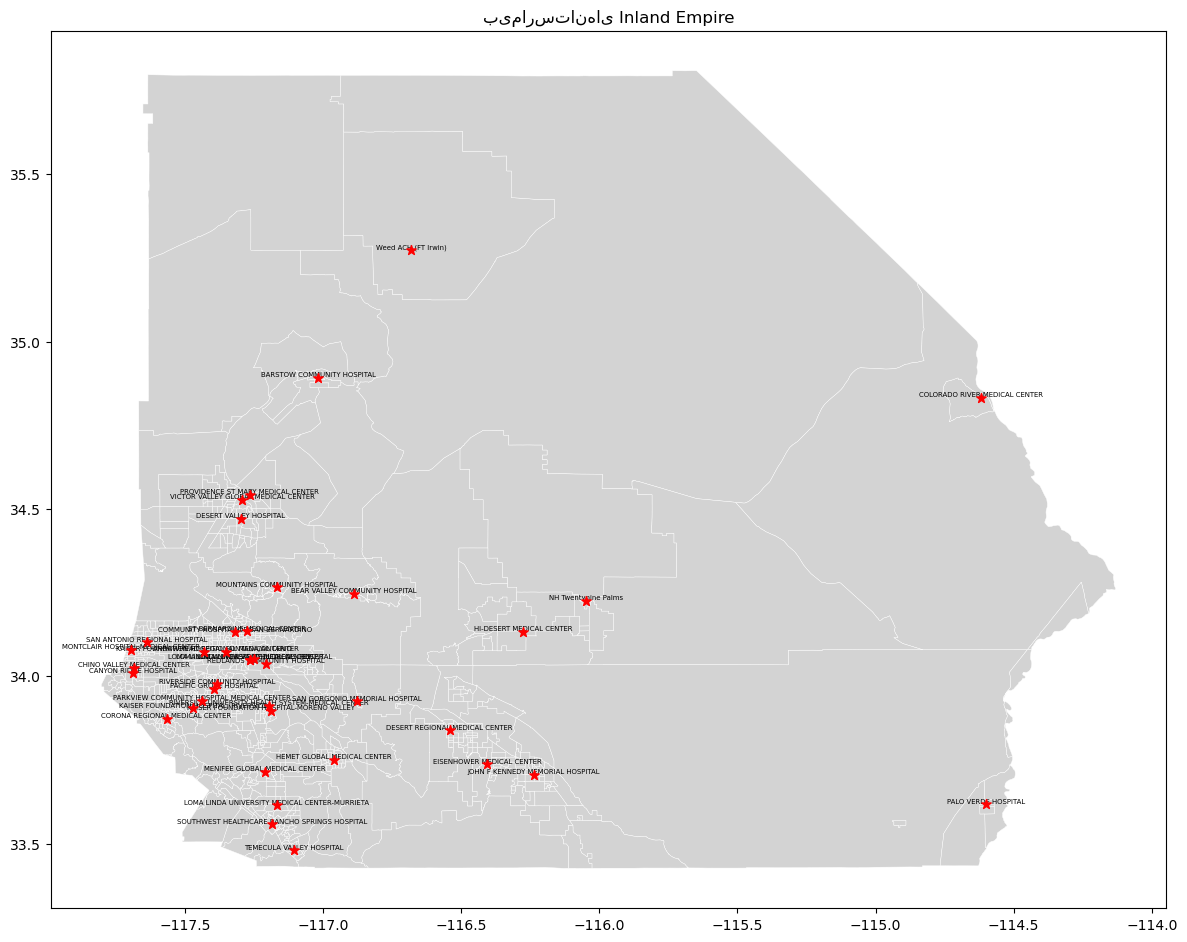

In [139]:
import geopandas as gpd
import matplotlib.pyplot as plt

tracts = gpd.read_file("ie_tracts_final.gpkg")
hospitals = gpd.read_file("hospitals_ie.gpkg")

fig, ax = plt.subplots(figsize=(12, 10))

tracts.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.3)
hospitals.plot(ax=ax, color='red', markersize=50, marker='*', zorder=5)

for idx, row in hospitals.iterrows():
    ax.annotate(row['Facility Name'], 
                xy=(row.geometry.x, row.geometry.y),
                fontsize=5, ha='center', va='bottom')

ax.set_title("Hospitals in the Inland Empire")
plt.tight_layout()
plt.savefig("hospitals_map.png", dpi=150)
plt.show()

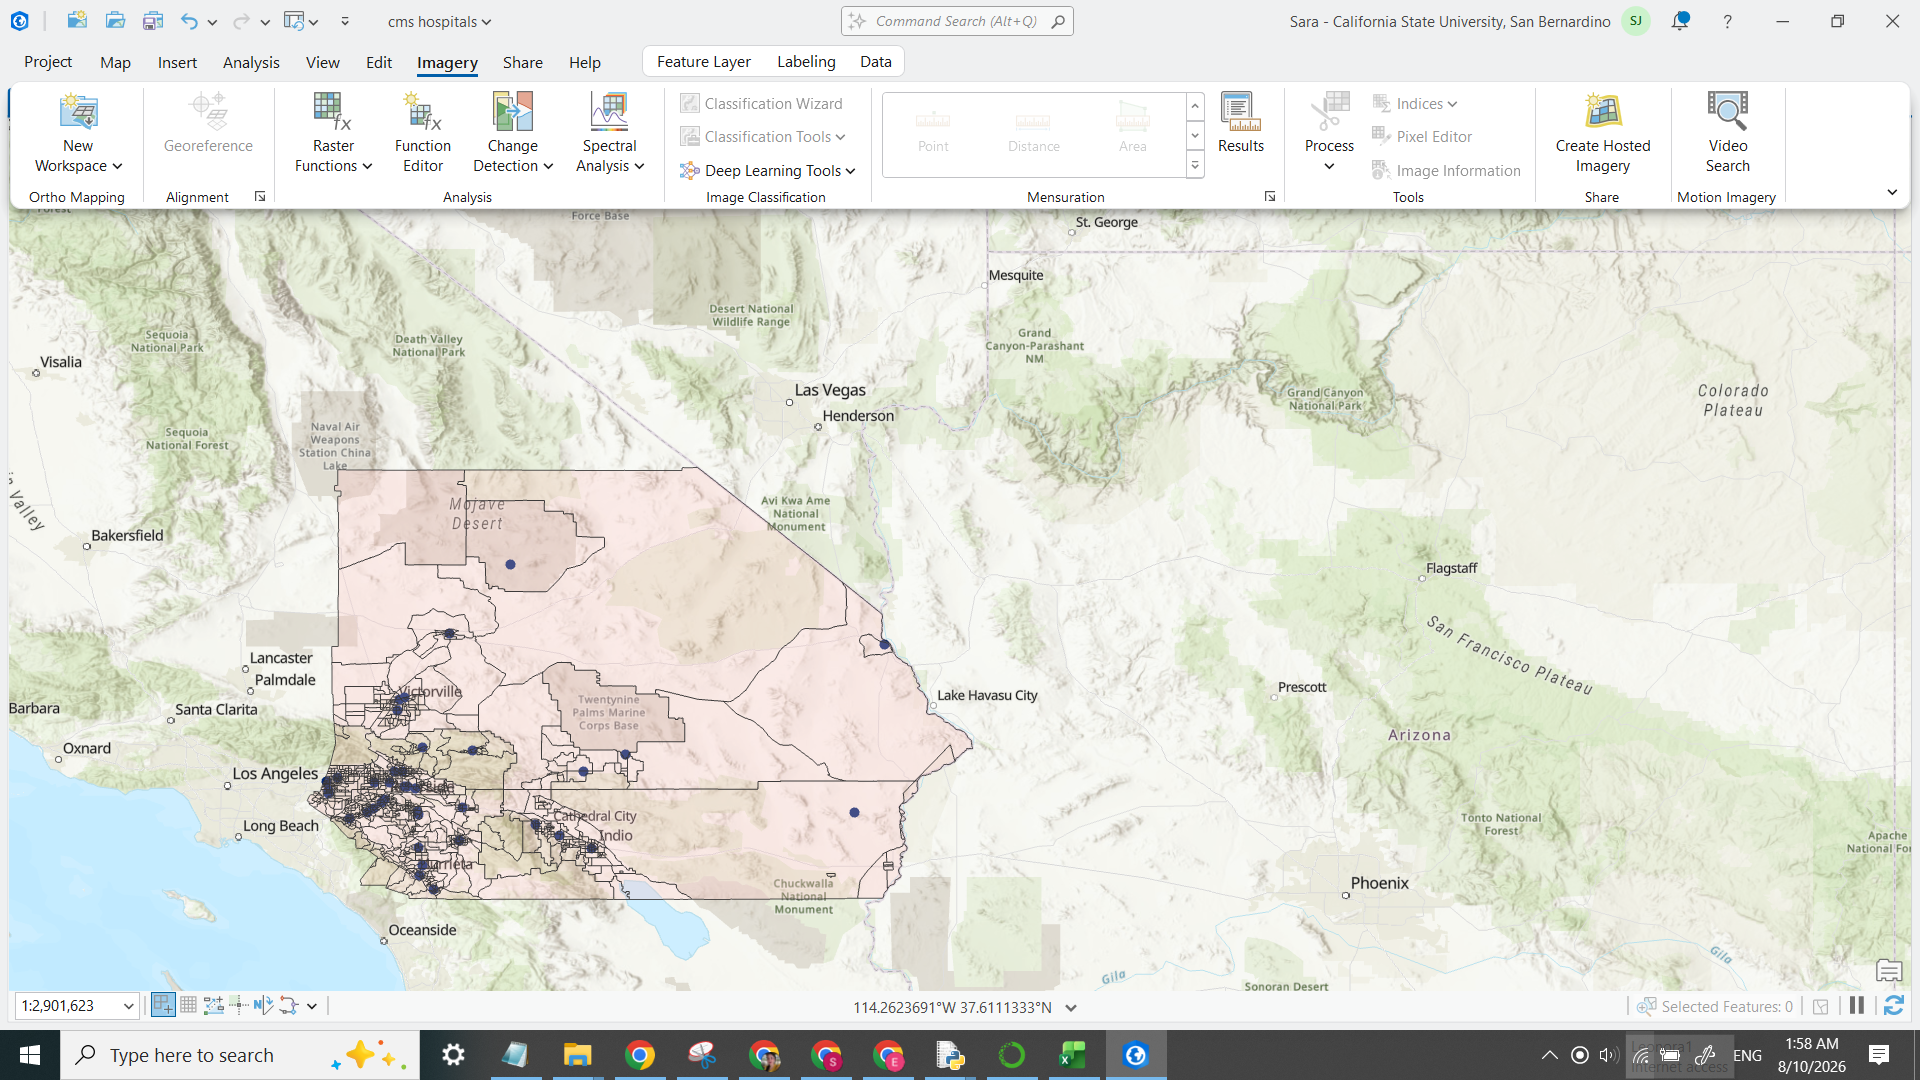![image.png]

# 10. HRSA Health Centers and Clinics

## 9.1 Filtering and Spatial Preparation of Health Center Locations

HRSA health center and service-delivery-site data represent an additional component of the healthcare supply system. Unlike the tract-level demographic and health datasets, each HRSA record represents an individual healthcare facility rather than a census tract.

Facilities located within Riverside and San Bernardino Counties are identified using the State and County Federal Information Processing Standard (FIPS) codes provided in the HRSA dataset. The study-area county codes are 06065 for Riverside County and 06071 for San Bernardino County.

The HRSA dataset also provides geocoded X and Y coordinates for facility locations. These coordinates are therefore used directly to construct point geometries, avoiding the need for a separate address-geocoding procedure. The resulting facility points are represented in WGS 84 (EPSG:4326) and exported as a GeoPackage for subsequent spatial accessibility analysis.

In [5]:
import pandas as pd
import geopandas as gpd

hrsa = pd.read_csv(
    "data/raw/Health_Center_Service_Delivery_and_LookAlike_Sites.csv",
    low_memory=False
)

# Filter using string match
hrsa_ie = hrsa[
    hrsa['State and County Federal Information Processing Standard Code']
    .isin(['06065', '06071'])
]

print(f"number of clinics: {len(hrsa_ie)}")

hrsa_gdf = gpd.GeoDataFrame(
    hrsa_ie,
    geometry=gpd.points_from_xy(
        hrsa_ie['Geocoding Artifact Address Primary X Coordinate'],
        hrsa_ie['Geocoding Artifact Address Primary Y Coordinate']
    ),
    crs="EPSG:4326"
)

hrsa_gdf.to_file(
    "health-centers-clinics_ie.gpkg",
    driver="GPKG"
)

print(hrsa_gdf[['Site Name', 'Site City', 'geometry']].head())
print("numbers:", len(hrsa_gdf))

number of cliniques: 208
                                    Site Name     Site City  \
20             SAC Health System Indio Clinic         Indio   
162  Morongo Basin Community Health Center-BH  Yucca Valley   
218                 DAP Health -Mobile Unit 3         Hemet   
252     Neighborhood Healthcare ~ Mead Valley        Perris   
259                       CNHF - Upland Admin        Upland   

                        geometry  
20   POINT (-116.21811 33.71871)  
162  POINT (-116.38981 34.13126)  
218  POINT (-116.96789 33.75999)  
252  POINT (-117.28451 33.84294)  
259   POINT (-117.64652 34.0886)  
numbers: 208


In [6]:
# Validate HRSA clinic GeoDataFrame

print("Number of clinics:", len(hrsa_gdf))
print("CRS:", hrsa_gdf.crs)
print("Missing geometries:", hrsa_gdf.geometry.isna().sum())
print("Empty geometries:", hrsa_gdf.geometry.is_empty.sum())
print("Valid geometries:", hrsa_gdf.geometry.is_valid.sum())

Number of clinics: 208
CRS: EPSG:4326
Missing geometries: 0
Empty geometries: 0
Valid geometries: 208


In [7]:
# Spatially validate HRSA facilities against the study-area tract boundaries

tracts = gpd.read_file("ie_tracts_final.gpkg")

# Make sure both layers use the same CRS
hrsa_check = hrsa_gdf.to_crs(tracts.crs)

study_area = tracts.geometry.union_all()

inside = hrsa_check.geometry.intersects(study_area)

print("Total HRSA facilities:", len(hrsa_check))
print("Inside study area:", inside.sum())
print("Outside study area:", (~inside).sum())

Total HRSA facilities: 208
Inside study area: 208
Outside study area: 0


### Spatial Validation of HRSA Facilities

The HRSA facility subset was validated spatially against the Inland Empire census tract boundaries. All 208 facilities selected using the Riverside and San Bernardino County FIPS codes were located within the study-area tract geometry.

This independent spatial validation confirms consistency between the attribute-based county filtering and the actual geographic coordinates of the HRSA facilities. No facilities were located outside the study area.

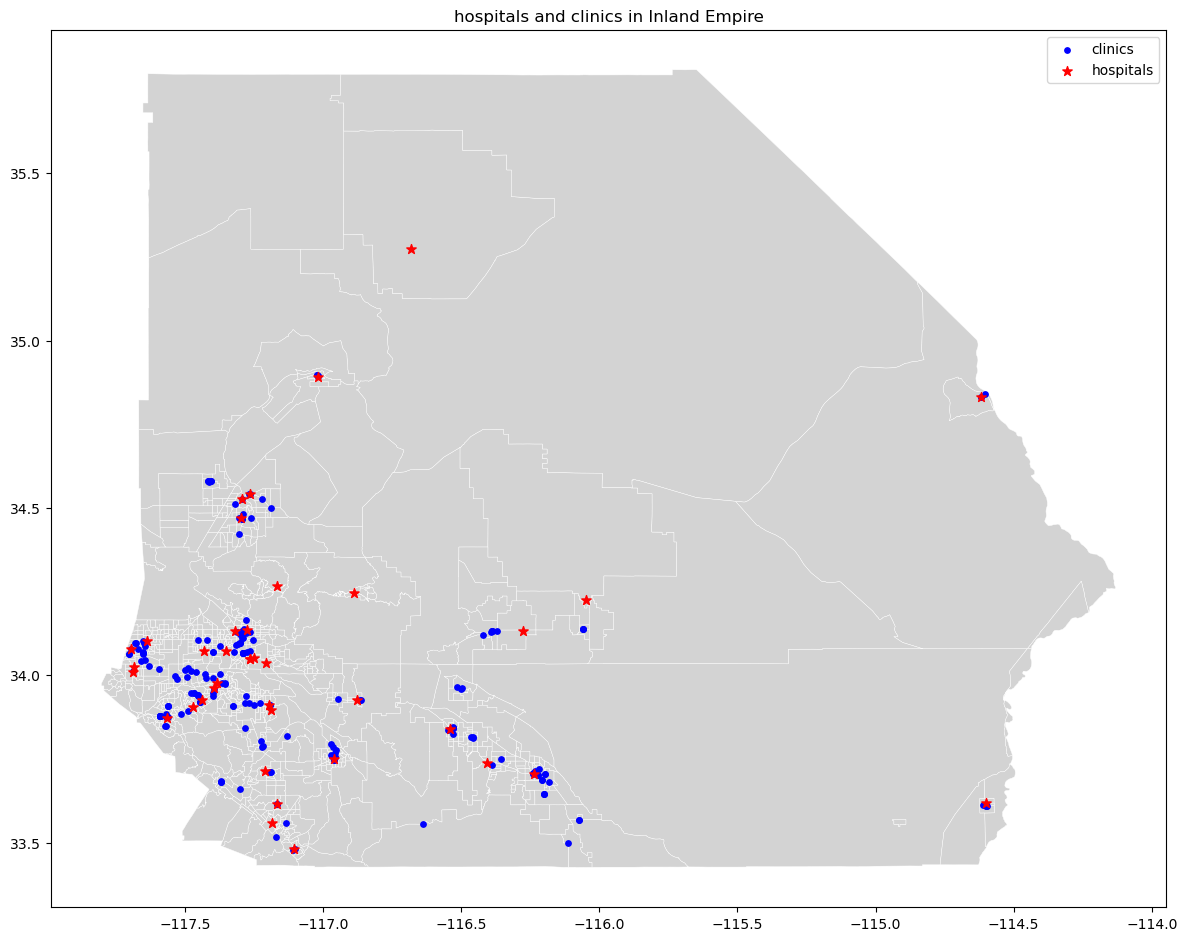

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt

tracts = gpd.read_file("ie_tracts_final.gpkg")
hospitals = gpd.read_file("hospitals_ie.gpkg")
clinics = gpd.read_file("health-centers-clinics_ie.gpkg")

fig, ax = plt.subplots(figsize=(12, 10))

tracts.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.3)
clinics.plot(ax=ax, color='blue', markersize=15, marker='o', zorder=4, label='clinics')
hospitals.plot(ax=ax, color='red', markersize=50, marker='*', zorder=5, label='hospitals')

ax.legend()
ax.set_title("hospitals and clinics in Inland Empire")
plt.tight_layout()
plt.savefig("facilities_map.png", dpi=150)
plt.show()

In [59]:
# Check CRS before spatial filtering of the road network
roads = gpd.read_file(
    "data/processed/socal.gpkg" ,
    layer="gis_osm_roads_free")
tracts = gpd.read_file("data/processed/ie_tracts_final.gpkg")
print(fiona.listlayers("data/raw/socal_gpkg_format/socal.gpkg"))

print("Roads CRS:", roads.crs)
print("Tracts CRS:", tracts.crs)
print("Same CRS:", roads.crs == tracts.crs)

['gis_osm_traffic_free', 'gis_osm_places_free', 'gis_osm_transport_free', 'gis_osm_natural_free', 'gis_osm_pois_free', 'gis_osm_pofw_free', 'gis_osm_places_a_free', 'gis_osm_pofw_a_free', 'gis_osm_transport_a_free', 'gis_osm_pois_a_free', 'gis_osm_natural_a_free', 'gis_osm_traffic_a_free', 'gis_osm_landuse_a_free', 'gis_osm_protected_areas_a_free', 'gis_osm_water_a_free', 'gis_osm_buildings_a_free', 'gis_osm_waterways_free', 'gis_osm_railways_free', 'gis_osm_roads_free', 'gis_osm_adminareas_a_free']
Roads CRS: GEOGCS["WGS 84 (CRS84)",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Longitude",EAST],AXIS["Latitude",NORTH],AUTHORITY["OGC","CRS84"]]
Tracts CRS: EPSG:4326
Same CRS: False
